In [ ]:
import pandas as pd
import geopandas as gpd
import seaborn as sns
import matplotlib.pyplot as plt
from shapely.geometry import Point

In [ ]:
listings = pd.read_csv(
    "../data/processed/listings_clean.csv",
    parse_dates=['first_review', 'last_review']
)

neighborhood_summary = pd.read_csv(
    "../data/processed/neighborhood_summary.csv"
)

In [ ]:
geometry = [
    Point(xy)
    for xy in zip(listings['longitude'], listings['latitude'])
]

gdf = gpd.GeoDataFrame(
    listings, geometry=geometry,
    crs='EPSG:4326'
)

In [ ]:
neighborhoods = gpd.read_file(
    "../data/raw/neighbourhoods.geojson"
)

In [ ]:
print("gdf CRS       :", gdf.crs)
print("neighborhoods CRS:", neighborhoods.crs)

if neighborhoods.crs != gdf.crs:
    neighborhoods = neighborhoods.to_crs(gdf.crs)
    print("Reprojected neighborhoods to:", neighborhoods.crs)

gdf CRS       : EPSG:4326
neighborhoods CRS: EPSG:4326


In [ ]:

map_data = neighborhoods.merge(
    neighborhood_summary,
    left_on='neighbourhood',
    right_on='neighborhood',
    how='left'
)

print(map_data[['neighbourhood', 'listing_count']])

      neighbourhood  listing_count
0       FOURTH WARD           17.0
1        FIRST WARD            9.0
2       SECOND WARD           43.0
3        THIRD WARD           33.0
4       EIGHTH WARD           12.0
5   FOURTEENTH WARD           29.0
6     ELEVENTH WARD           30.0
7    FIFTEENTH WARD           15.0
8      TWELFTH WARD            3.0
9        SIXTH WARD          106.0
10       FIFTH WARD           19.0
11     SEVENTH WARD           13.0
12       NINTH WARD           36.0
13       TENTH WARD           49.0
14  THIRTEENTH WARD           39.0
15              NaN            NaN
16              NaN            NaN


In [ ]:
ward_mapping = {
    'FIRST WARD':     'W1',
    'SECOND WARD':    'W2',
    'THIRD WARD':     'W3',
    'FOURTH WARD':    'W4',
    'FIFTH WARD':     'W5',
    'SIXTH WARD':     'W6',
    'SEVENTH WARD':   'W7',
    'EIGHTH WARD':    'W8',
    'NINTH WARD':     'W9',
    'TENTH WARD':     'W10',
    'ELEVENTH WARD':  'W11',
    'TWELFTH WARD':   'W12',
    'THIRTEENTH WARD':'W13',
    'FOURTEENTH WARD':'W14',
    'FIFTEENTH WARD': 'W15'
}

map_data['ward_label'] = map_data['neighbourhood'].map(ward_mapping)

# Verify labels are assigned correctly
print(map_data[['neighbourhood', 'ward_label']])

      neighbourhood ward_label
0       FOURTH WARD         W4
1        FIRST WARD         W1
2       SECOND WARD         W2
3        THIRD WARD         W3
4       EIGHTH WARD         W8
5   FOURTEENTH WARD        W14
6     ELEVENTH WARD        W11
7    FIFTEENTH WARD        W15
8      TWELFTH WARD        W12
9        SIXTH WARD         W6
10       FIFTH WARD         W5
11     SEVENTH WARD         W7
12       NINTH WARD         W9
13       TENTH WARD        W10
14  THIRTEENTH WARD        W13
15              NaN        NaN
16              NaN        NaN


In [ ]:

def draw_ward_labels(ax, map_data):
    for idx, row in map_data.iterrows():

        # Skip missing geometry
        if row['geometry'] is None:
            continue

        # Skip rows where ward_label is NaN (unmatched / null neighbourhood)
        if pd.isna(row.get('ward_label')):
            continue

        centroid = row['geometry'].centroid

        ax.text(
            centroid.x, centroid.y,
            row['ward_label'],
            fontsize=9,
            fontweight='bold',
            ha='center',
            va='center',
            bbox=dict(
                boxstyle='round,pad=0.2',
                facecolor='white',
                alpha=0.6,
                edgecolor='none'
            )
        )

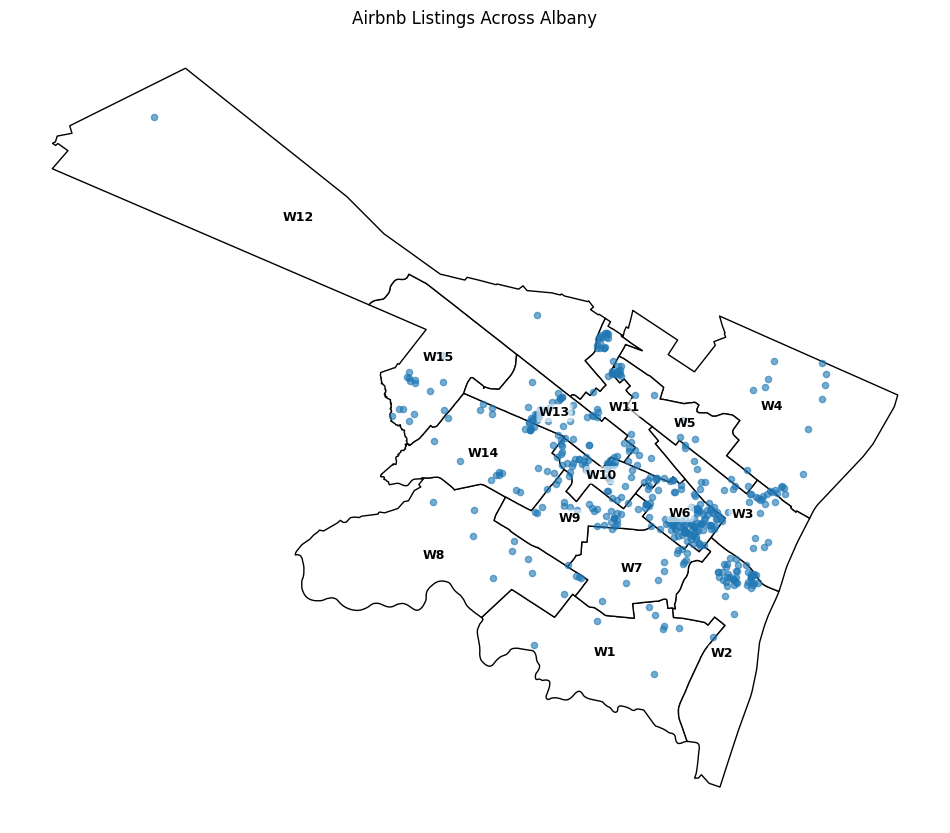

In [ ]:

fig, ax = plt.subplots(figsize=(12, 12))

neighborhoods.plot(ax=ax, color='white', edgecolor='black')
gdf.plot(ax=ax, markersize=20, alpha=0.6)

draw_ward_labels(ax, map_data)

plt.title("Airbnb Listings Across Albany")
plt.axis('off')
plt.show()

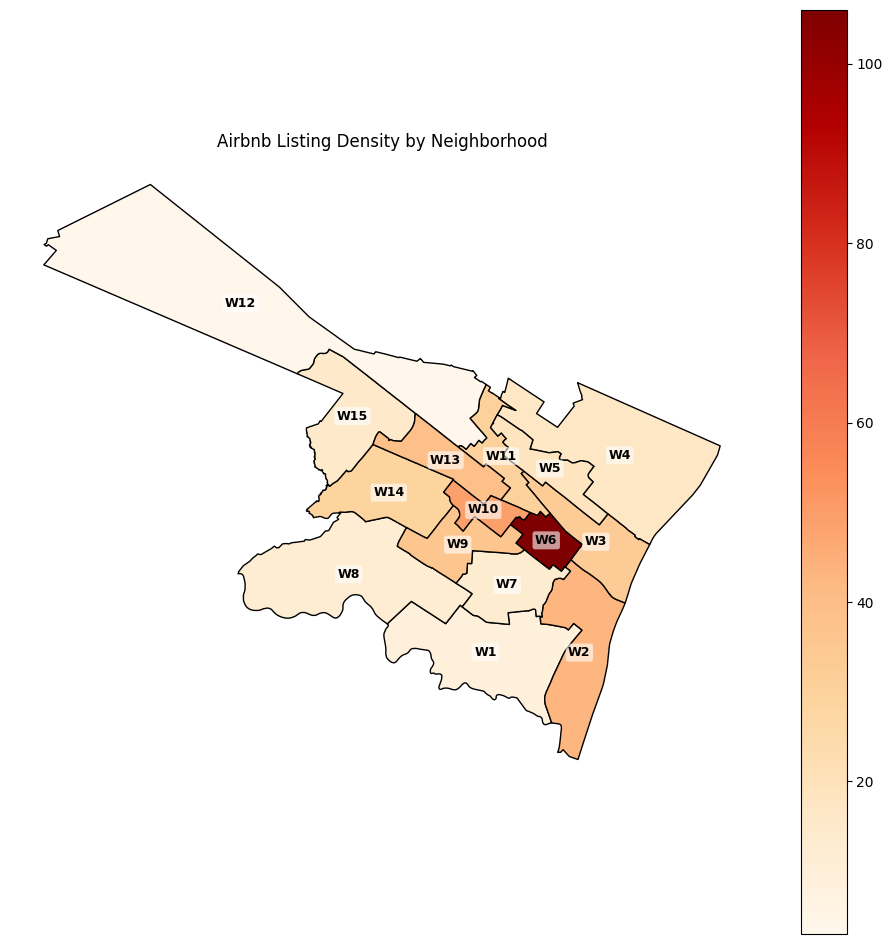

In [ ]:

fig, ax = plt.subplots(figsize=(12, 12))

map_data.plot(
    column='listing_count',
    cmap='OrRd',
    legend=True,
    edgecolor='black',
    ax=ax
)

draw_ward_labels(ax, map_data)

plt.title("Airbnb Listing Density by Neighborhood")
plt.axis('off')
plt.show()

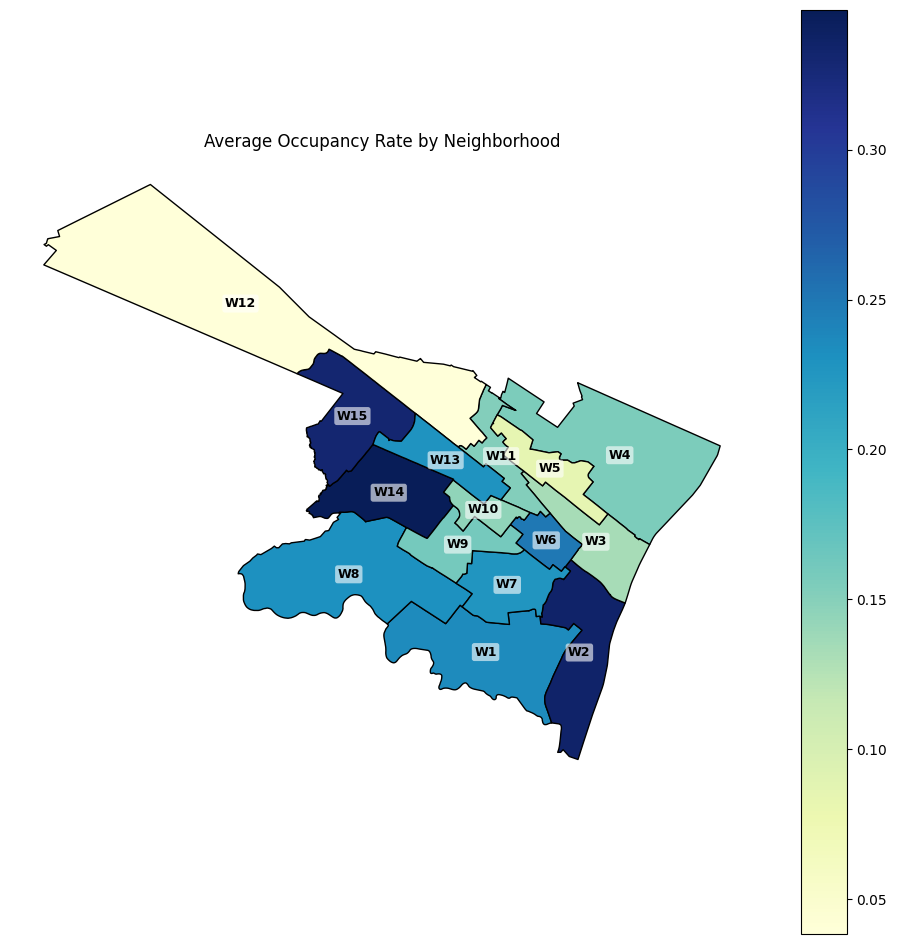

In [ ]:

fig, ax = plt.subplots(figsize=(12, 12))

map_data.plot(
    column='occupancy_rate',
    cmap='YlGnBu',
    legend=True,
    edgecolor='black',
    linewidth=1,
    ax=ax
)

draw_ward_labels(ax, map_data)

plt.title("Average Occupancy Rate by Neighborhood")
plt.axis('off')
plt.show()

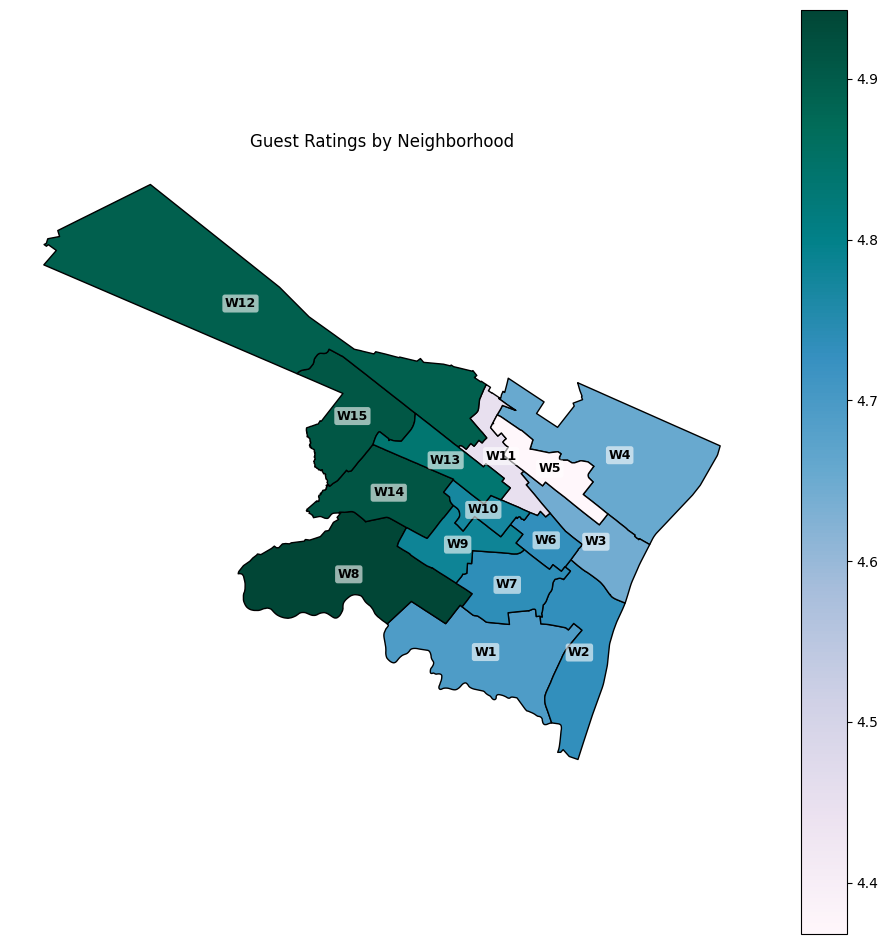

In [ ]:

fig, ax = plt.subplots(figsize=(12, 12))

map_data.plot(
    column='review_scores_rating',
    cmap='PuBuGn',
    legend=True,
    edgecolor='black',
    ax=ax
)

draw_ward_labels(ax, map_data)

plt.title("Guest Ratings by Neighborhood")
plt.axis('off')
plt.show()

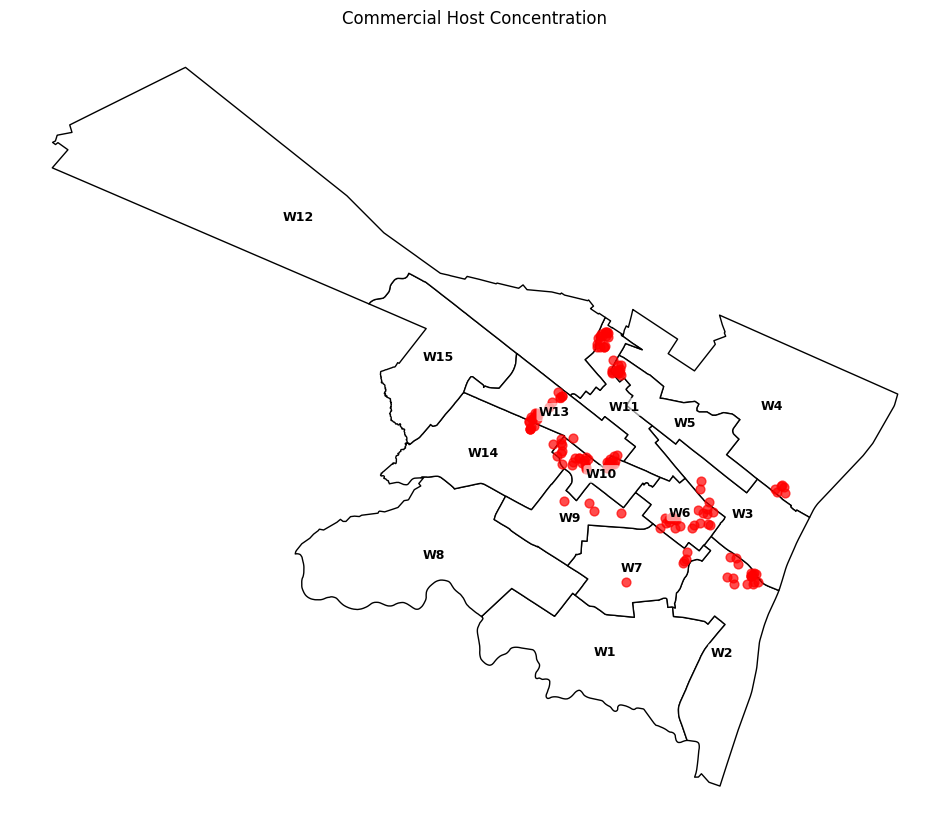

In [ ]:

commercial_hosts = gdf[gdf['calculated_host_listings_count'] >= 10]

fig, ax = plt.subplots(figsize=(12, 12))

neighborhoods.plot(ax=ax, color='white', edgecolor='black')
commercial_hosts.plot(ax=ax, markersize=40, alpha=0.7, color='red')

draw_ward_labels(ax, map_data)

plt.title("Commercial Host Concentration")
plt.axis('off')
plt.show()

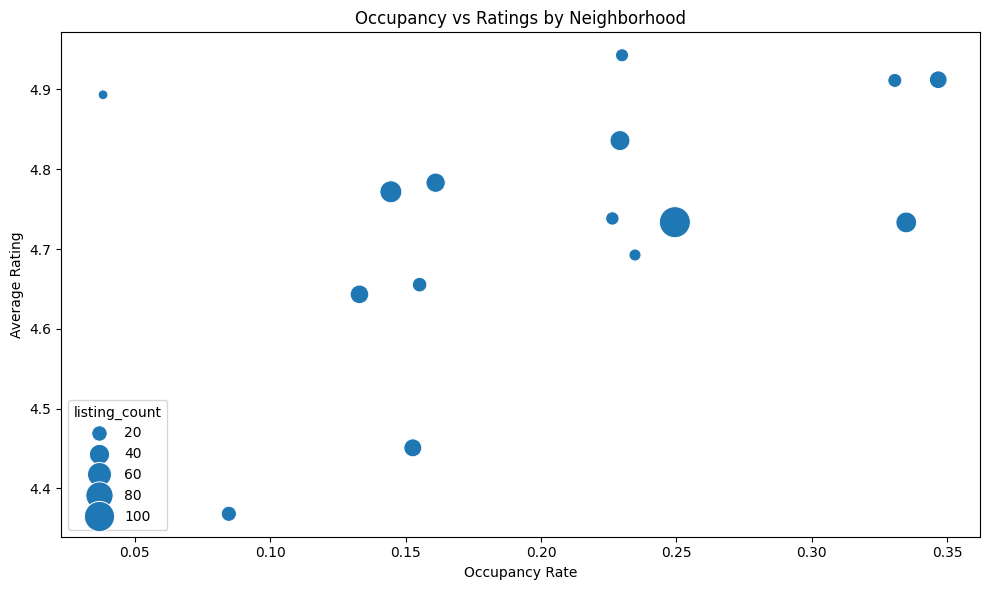

In [ ]:

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=neighborhood_summary,
    x='occupancy_rate',
    y='review_scores_rating',
    size='listing_count',
    sizes=(50, 500)
)

plt.title("Occupancy vs Ratings by Neighborhood")
plt.xlabel("Occupancy Rate")
plt.ylabel("Average Rating")
plt.tight_layout()
plt.show()